In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
sys.path.append(os.path.abspath("./"))

print(os.getpid())
%cd ../../

import pylib.mix as mix
import carleman as ca
from matplotlib import colors
plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

14084
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py


In [38]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

# colors_     = ["blue", "red", "green", "gray", "black"]
colors_     = ["orange", "red", "green", "gray", 'yellow', 'purple', 'pink', 'brown',]
linestyles_ = ["-", "--", "--", ":"]

two attractors and an unstable point

System coefficients:
a = 1.600
b = 0.900
c = 0.100

Nt: 1024
init. cond.:   0.98 




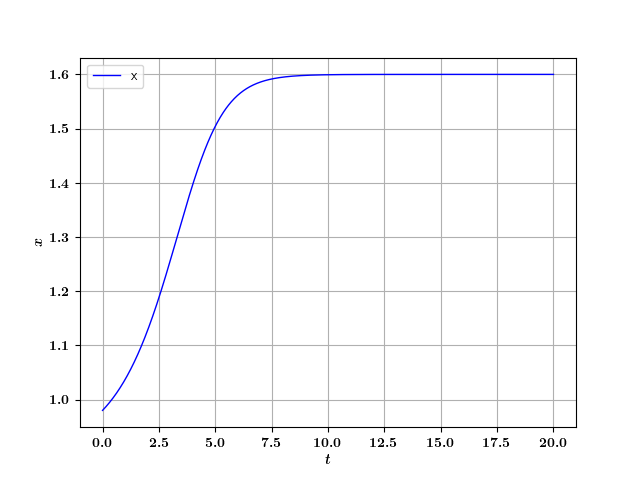

In [46]:
# ---------------------------------------------------------------
# --- Prepare the system ---
# ---------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(ca)
def choose_case(N_nl, sel_case):
    Nx = 1  # the number of degrees of freedom
    F_terms, sys_coefs, return_sys, shift_coefs = None, None, None, None

    # --- 2 attractors and an unstable point ---
    if sel_case == 0:
        print("two attractors and an unstable point")
        
        tmax, nt = 20, 10
        
        # case_title, x_init, a1, b1, c1 = "",    [0.98], 1.6, 0.9, 0.8 
        case_title, x_init, a1, b1, c1 = "FA",  [0.98], 1.6, 0.9, 0.1  

        sys_coefs = {}
        sys_coefs["a"] = a1
        sys_coefs["b"] = b1
        sys_coefs["c"] = c1

        def return_sys(ss):
            a1 = ss["a"]
            b1 = ss["b"]
            c1 = ss["c"]

            F_terms = [None] * (N_nl + 1)
            for ii_nl in range(N_nl + 1):
                F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))

            F_terms[3][0,0], F_terms[2][0,0], F_terms[1][0,0], F_terms[0][0,0] = \
                -1., (a1 + b1 + c1), -(a1*b1 + a1*c1 + b1*c1), a1*b1*c1
            return F_terms

        def shift_coefs(ss, zeta):
            ss_new = {}
            for key, value in ss.items():
                ss_new[key] = value - zeta[0]
            # another option: introduce zeta_x directly to the F_terms:
            #   in this case, ss_new["xi_x"] += zeta[0];
            #   this another option is taken in higher dimensional problems.
            return ss_new
        
        # --- Print the system ---
        print("\nSystem coefficients:")
        for key, value in sys_coefs.items():
            print("{:s} = {:0.3f}".format(key, value))
        print()

        F_terms = return_sys(sys_coefs)
        F = [
            lambda x: F_terms[0][0,0] + F_terms[1][0,0] * x[0] + F_terms[2][0,0] * x[0]**2 + F_terms[3][0,0] * x[0]**3
        ]
    # -----------------------------------------------------------------
    return F, tmax, nt, Nx, x_init, sys_coefs, return_sys, shift_coefs, case_title
# ------------------------------------------------------------------------------
sel_case_ = 0 
N_nl_orig_ = 3

F_, tmax_, nt_, Nx_, x_init_ref_, sys_coefs_, return_sys_, shift_coefs_, case_title_ = \
    choose_case(N_nl_orig_, sel_case = sel_case_)
Nt_ = 1 << nt_
t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]

print("Nt: {:d}".format(Nt_))
print("init. cond.: ", end = "")
mix.print_array(x_init_ref_, ff = [6, 2, "f"])

# --- Standard method (for reference) ---
sol_ref_, t_ref_ = ca.analyse_classical(x_init_ref_, t_, F_)

In [50]:
# --------------------------------------------------------------------
# --- Carleman linearization ---
# --------------------------------------------------------------------
mix.reload_module(ca)
N_nl = 6   # should be >= N_nl_orig_

# # --- Standard embedding ---
# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_orig(x_init_ref_, N_nl, N_nl_orig_, t_, return_sys_(sys_coefs_))
# radii_emb_ = None
# xi_case_ = ""

# # --- Piecewise embedding ---
# zeta_th = 0.6
# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_global(
#     x_init_ref_, N_nl, N_nl_orig_, t_, 
#     sys_coefs_, return_sys_, shift_coefs_,
#     zeta_th = zeta_th
# )
# radii_emb_ = None
# xi_case_ = "xi{:0.2f}".format(zeta_th)
# del zeta_th

# --- Piecewise adaptive embedding ---
zeta_max, err_tolerance, zeta_init = 1.0, 1e-4, 1.0
# zeta_max, err_tolerance, zeta_init = 0.2, 1e-4, 0.2
# zeta_max, err_tolerance, zeta_init = 1.0, 1e-10, 1.0
sol_emb_, t_emb_, case_emb_, radii_emb_ = ca.solve_carleman_global_adaptive(
    x_init_ref_, N_nl, N_nl_orig_, t_, 
    sys_coefs_, return_sys_, shift_coefs_, 
    zeta_init_ = zeta_init, 
    err_tolerance_ = err_tolerance,
    zeta_min_    = 1e-4,
    zeta_step_   = 0.01,
    zeta_thresh_ = 0.12,
    zeta_max_ = zeta_max
)
xi_case_ = "max{:0.2f}_tol{:0.3e}".format(zeta_max, err_tolerance)
del zeta_max, err_tolerance, zeta_init

Take a smaller chart: new zeta = 9.900e-01
Take a smaller chart: new zeta = 9.800e-01
Take a smaller chart: new zeta = 9.700e-01
Take a smaller chart: new zeta = 9.600e-01
Take a smaller chart: new zeta = 9.500e-01
Take a smaller chart: new zeta = 9.400e-01
Take a smaller chart: new zeta = 9.300e-01
Take a smaller chart: new zeta = 9.200e-01
Take a smaller chart: new zeta = 9.100e-01
Take a smaller chart: new zeta = 9.000e-01
Take a smaller chart: new zeta = 8.900e-01
Take a smaller chart: new zeta = 8.800e-01
Take a smaller chart: new zeta = 8.700e-01
Take a smaller chart: new zeta = 8.600e-01
Take a smaller chart: new zeta = 8.500e-01
Take a smaller chart: new zeta = 8.400e-01
Take a smaller chart: new zeta = 8.300e-01
Take a smaller chart: new zeta = 8.200e-01
Take a smaller chart: new zeta = 8.100e-01

--- t, zeta: 5.896e+00, 8.100e-01 ---

--- t, zeta: 2.000e+01, 8.100e-01 ---
Done


write data to a file: ./jupyter-notebooks/Carleman/results//REF_FA_1D_max1.00_tol1.000e-04_x.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_FA_1D_max1.00_tol1.000e-04_PAE_x.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_FA_1D_max1.00_tol1.000e-04_PAE_err_x.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_FA_1D_max1.00_tol1.000e-04_PAE_radius.dat


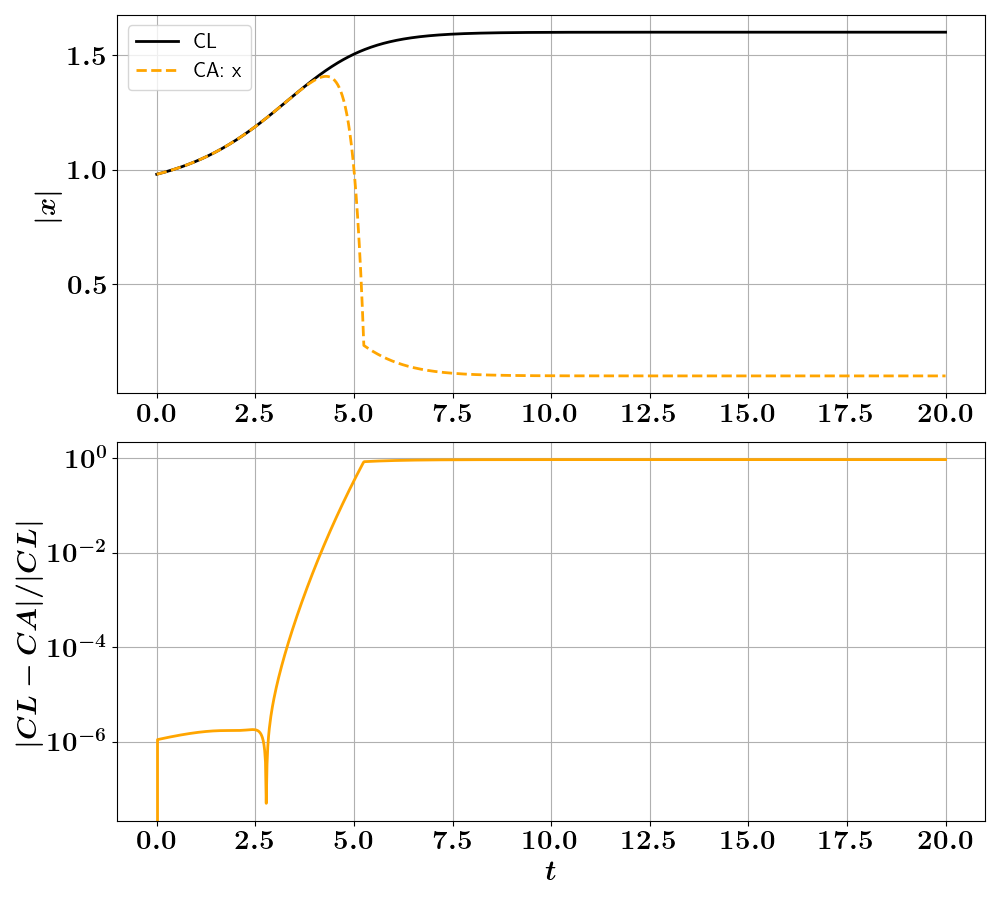

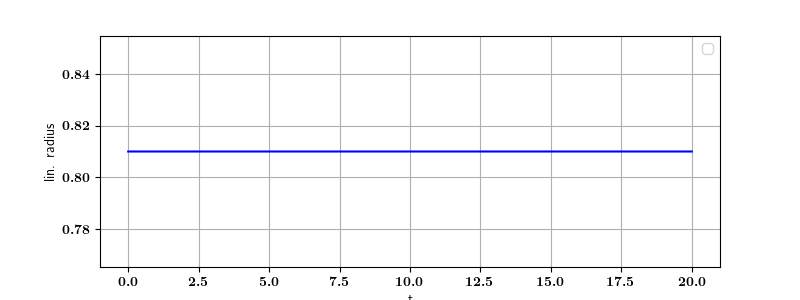

In [52]:
# --------------------------------------------------------------------
# --- Compare trajectories ---
# --------------------------------------------------------------------
mix.reload_module(ca)
ca.compare_trajectory_cl_and_carleman(
    t_ref_, sol_ref_, t_emb_, sol_emb_,
    flag_save = True, 
    path_save = path_save_, 
    case_title = case_title_ + "_1D_" + xi_case_, case_emb = case_emb_,
    fontsize = 20, fig_size = (10,9),
    radii_emb = radii_emb_,
    flag_var_semilogy = False
)